# Trees, Forests, and Boosting

Alex Ronczewski  
2026-06-21

## Outline

### Prerequisites

-   Notebook 2 of this stream: ridge and lasso, variable selection, and
    the train/test/cross-validate recipe
-   Comfort with `pandas` and basic Python at the COMET-intermediate
    level
-   No prior knowledge of trees is assumed; regression trees, forests,
    and boosting are all introduced here

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Describe what a **regression tree** does: split the feature space
    into boxes and predict the average outcome in each box.
2.  Fit a single decision tree and **read its splits** off a diagram.
3.  Explain why a deep tree **overfits**, and identify `max_depth` as
    its flexibility hyperparameter.
4.  Choose the depth of a tree by cross-validation, reusing the recipe
    from Notebook 1.
5.  Explain **bagging** and fit a **random forest**, and say why
    averaging many trees lowers variance.
6.  Read a table of **feature importances** as a predictive diagnostic.
7.  Describe in one sentence how **boosting** differs from bagging.
8.  Explain why a random forest’s predictions and importances are
    **not** causal effects.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42  # fix randomness so splits, folds, and forests are reproducible

## 1. A Third way to be Flexible

So far this stream has shown flexibility in two different ways. In
Notebook 1, k-nearest-neighbours was flexible because it averaged
whatever points sat nearby, and the parameter $k$ set how many. In
Notebook 2, linear models were flexible because we could pour in
covariates, and the penalty $\lambda$ kept their coefficients in check.

This notebook introduces a third kind of flexibility. A **decision
tree** does not measure distance and does not fit a line. It carves the
feature space into rectangular boxes by asking a sequence of yes-or-no
questions about one feature at a time, and to predict a new case it
returns the average outcome of the training points that landed in the
same box.

This will be very new to most of you, so we’ll build up to this,
starting with a single tree that we can draw and read. Then we’ll watch
it overfit, just as $k=1$ KNN overfit in Notebook 1 and OLS overfit with
too many controls in Notebook 2. Then we fix the overfitting by
averaging many trees into a **random forest**, and we close with a brief
look at **boosting**, a second way to combine trees. Throughout, we’re
still predicting, and the causal turn comes in Notebook 4.

### 1.1 The data: back to the 401(k) households

We return to the **401(k)** data from Notebook 1: one row per U.S.
household, the net financial assets `net_tfa` (in thousands of dollars)
as the target, and ten features of the household, including `e401`,
whether the household is eligible for a 401(k). We re-use this data as
we have a test MSE of about 2654 which we will try and beat, and we can
ask the question that matters when choosing between methods: which one
predicts new households best.

In [2]:
savings = pd.read_csv("datasets/Pension401k.csv")

features = ["age", "inc", "educ", "fsize", "marr",
            "twoearn", "db", "pira", "hown", "e401"]
target = "net_tfa"

y = savings[target].to_numpy()
X = savings[features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE)

print("Training households:", len(X_train))
print("Test households    :", len(X_test))

Training households: 6940
Test households    : 2975

One thing we do **not** have to do this time is scale the features. A
tree split is a question like “is income above 65?”, and the answer does
not change if we measure income in dollars or in thousands of dollars:
the ordering of the households is all that matters, not the units. This
is different from Notebook 1, where KNN measured distance and so needed
every feature on a common scale, and from Notebook 2, where the penalty
acted on coefficient sizes. Trees are blind to scale, so there is no
`StandardScaler` here except inside the KNN model we carry over for
comparison.

In [3]:
baseline_mse = mean_squared_error(y_test, np.full_like(y_test, y_train.mean()))

knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=15))
knn.fit(X_train, y_train)
knn_mse = mean_squared_error(y_test, knn.predict(X_test))

print(f"Predict-the-mean test MSE        : {baseline_mse:.1f}")
print(f"KNN (k=15, from Notebook 1) test MSE: {knn_mse:.1f}")

Predict-the-mean test MSE        : 3708.3
KNN (k=15, from Notebook 1) test MSE: 2654.4

Predicting the average savings of every household, ignoring all ten
features, gives a test MSE of about 3708. That is the floor any real
model must clear. The KNN model from Notebook 1 clears it at about 2654.
Those two numbers, 3708 and 2654, are what we will try and beat.

## 2. A single decision tree

A regression tree is built greedily, one split at a time. It looks
across every feature and every possible cut point, and chooses the
single split that most reduces the mean squared error of the two groups
it creates. Then it repeats the search inside each group, and again
inside those, and so on. The result is a set of boxes, called
**leaves**, and the prediction for any household is just the average
training value in whatever leaf the household falls into.

The clearest way to see this is to grow a shallow tree, shallow enough
to draw, and read it.

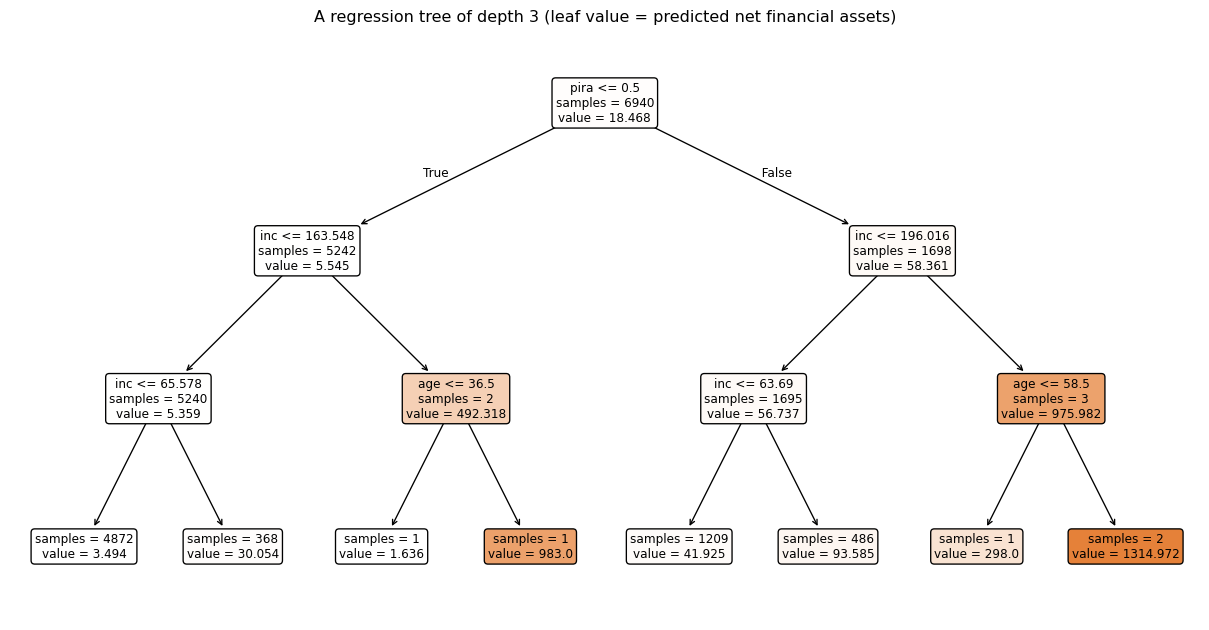

In [4]:
tree3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
tree3.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(tree3, feature_names=features, filled=True, rounded=True,
          impurity=False, fontsize=9)
plt.title("A regression tree of depth 3 (leaf value = predicted net financial assets)")
plt.show()

Read the tree from the top. The very first question it asks is whether
the household owns an IRA (`pira`): owning one separates committed
savers from everyone else with a single yes/no, which is why the tree
chose it first. From there the splits are mostly about income, with age
deciding some of the deeper ones. Follow any path down to a leaf and you
reach a predicted value, and those values climb steeply: from a few
thousand dollars in the leaves of low-income non-savers up into the
hundreds of thousands for older, high-income IRA owners. The tree has
rediscovered, with no equation, what a regression would also find:
savings track income, age, and whether a household already holds
retirement accounts.

In [5]:
print(f"Depth-3 tree test MSE: {mean_squared_error(y_test, tree3.predict(X_test)):.1f}")

Depth-3 tree test MSE: 3034.7

This little tree already beats predicting the mean, though it is still
short of KNN. It is also easy to read, which is part of why trees are
popular. But the depth-3 limit was ours to impose. What happens if we
let the tree grow as deep as it likes?

### 2.1 When Trees overfit

If we remove the depth limit, the tree keeps splitting until it can’t
anymore, in the limit isolating nearly one training household per leaf.

In [6]:
deep_tree = DecisionTreeRegressor(random_state=RANDOM_STATE)  # no depth limit
deep_tree.fit(X_train, y_train)

print(f"Deep tree depth        : {deep_tree.get_depth()}")
print(f"Deep tree training MSE : {mean_squared_error(y_train, deep_tree.predict(X_train)):.1f}")
print(f"Deep tree test MSE     : {mean_squared_error(y_test, deep_tree.predict(X_test)):.1f}")

Deep tree depth        : 37
Deep tree training MSE : 0.0
Deep tree test MSE     : 4739.5

The tree grew 37 levels deep, and its training MSE is essentially zero.
It has put almost every training household in a leaf of its own and
reads the value straight back, so on the training data it is never
wrong. We have seen this failure twice already: it is the $k=1$
nearest-neighbour problem from Notebook 1 and the too-many-coefficients
problem from Notebook 2, just with trees. The test MSE, 4739.5, is
*worse* than the depth-3 tree, worse than KNN, and worse even than
predicting the mean. A tree deep enough to memorise the training
households carries none of that memorisation over to new ones.

So `max_depth` is the tree’s flexibility parameter, playing the role
that $k$ played for KNN and $\lambda$ played for ridge and lasso. A
shallow tree is rigid and high-bias, a deep tree is flexible and
high-variance, and somewhere in between is a depth that predicts best.

### 2.2 Choosing the depth

We find that depth the same way we found $k$ in Notebook 1: plot it and
watch both errors.

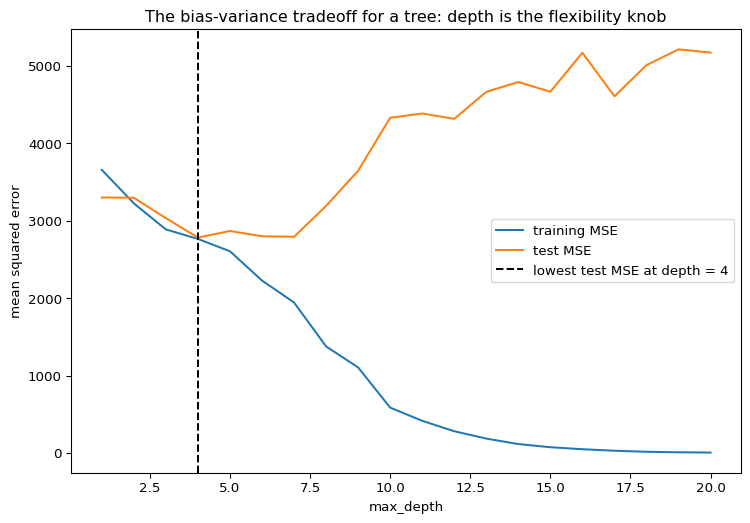

In [7]:
depths = range(1, 21)
train_errors, test_errors = [], []
for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    train_errors.append(mean_squared_error(y_train, t.predict(X_train)))
    test_errors.append(mean_squared_error(y_test, t.predict(X_test)))

best_depth_by_test = list(depths)[int(np.argmin(test_errors))]

plt.figure(figsize=(9, 6))
plt.plot(list(depths), train_errors, label="training MSE")
plt.plot(list(depths), test_errors, label="test MSE")
plt.axvline(best_depth_by_test, color="black", linestyle="--",
            label=f"lowest test MSE at depth = {best_depth_by_test}")
plt.xlabel("max_depth")
plt.ylabel("mean squared error")
plt.title("The bias-variance tradeoff for a tree: depth is the flexibility knob")
plt.legend()
plt.show()

It is the same picture as Notebook 1, drawn against depth instead of
$k$, as that is the corresponding hyperparameter for trees. Training MSE
falls steadily toward zero as the tree grows, because a deeper tree can
always cut the training data more finely. Test MSE traces the
bias-variance U-shape: shallow trees (depth 1 to 3) are too rigid and
sit a little high, it bottoms out across a flat, noisy stretch from
roughly depth 4 to 7, and beyond depth 8 it climbs steadily as the tree
fits noise. The dashed line marks the lowest test MSE here, at depth 4,
but several neighbouring depths are similar. That flat, wiggly bottom is
why we don’t pick the depth by eye, and turn to cross-validation
instead.

We choose it with cross-validation, never touching the test set, like in
notebook 1.

In [8]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_errors = []
for d in depths:
    scores = cross_val_score(
        DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE),
        X_train, y_train, cv=kfold, scoring="neg_mean_squared_error")
    cv_errors.append(-scores.mean())

best_depth = list(depths)[int(np.argmin(cv_errors))]
tree_best = DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE).fit(X_train, y_train)
tree_mse = mean_squared_error(y_test, tree_best.predict(X_test))

print(f"Cross-validation chose max_depth = {best_depth}")
print(f"Tuned single-tree test MSE: {tree_mse:.1f}")

Cross-validation chose max_depth = 4
Tuned single-tree test MSE: 2784.9

Cross-validation decides on a shallow depth of 4, and the tuned tree
scores just behind KNN, close enough that a single well-chosen tree is
already a competitive predictor. We have now run the same four steps as
in Notebook 1: split off a test set, cross-validate on the training data
to choose the parameter, pick the best value, and evaluate once on the
sealed test set.

The issue is that even the best single tree is a high-variance object.
Shift a few training households and the greedy search can pick a
different first split, and the whole tree below it rearranges. We can
see that instability directly. Below we pick five test households
spanning low to high savings, and ask forty trees, each fit to a
different bootstrap resample of the training data, to predict each one.
**Bootstrapping**: drawing, with replacement, many resamples of the
training data the same size as the original (you may have seen this
concept in ECON 226 and 326). Every grey dot is one tree’s guess; the
red mark is the forest’s single answer.

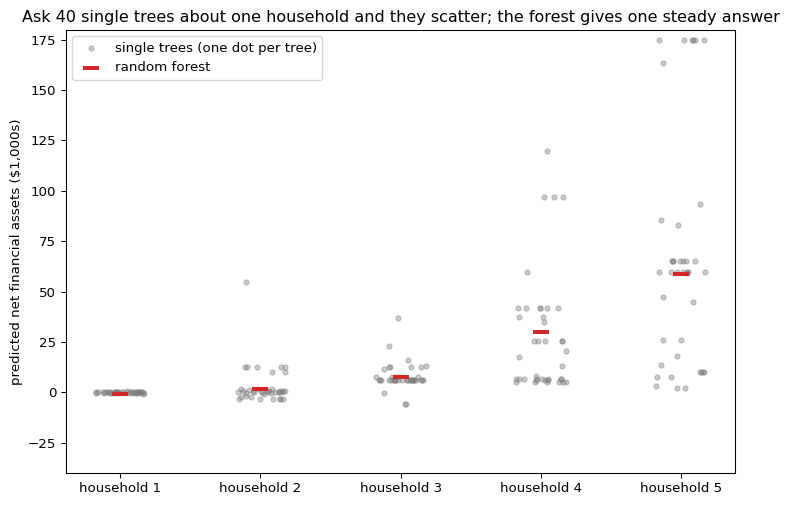

In [9]:
forest_demo = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
forest_demo.fit(X_train, y_train)

# Five test households spanning low to high predicted savings.
order = np.argsort(forest_demo.predict(X_test))
picks = [order[int(q * (len(order) - 1))] for q in [0.2, 0.4, 0.6, 0.8, 0.9]]
X_pick = X_test.iloc[picks]

# Ask forty single trees, each fit to its own bootstrap resample, about each household.
rng = np.random.default_rng(0)
tree_guesses = np.array([
    DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train.iloc[idx], y_train[idx]).predict(X_pick)
    for idx in (rng.integers(0, len(X_train), len(X_train)) for _ in range(40))
])

plt.figure(figsize=(9, 6))
for j in range(len(picks)):
    xj = (j + 1) + rng.uniform(-0.18, 0.18, len(tree_guesses))
    plt.scatter(xj, tree_guesses[:, j], s=14, alpha=0.4, color="grey",
                label="single trees (one dot per tree)" if j == 0 else None)
plt.scatter(range(1, len(picks) + 1), forest_demo.predict(X_pick), color="tab:red",
            s=160, marker="_", linewidth=3, zorder=5, label="random forest")
plt.xticks(range(1, len(picks) + 1), [f"household {i+1}" for i in range(len(picks))])
plt.ylim(-40, 180)
plt.ylabel("predicted net financial assets ($1,000s)")
plt.title("Ask 40 single trees about one household and they scatter; the forest gives one steady answer")
plt.legend()
plt.show()

For any one household the grey dots are spread all over: ask a different
resample and a single tree shifts its answer by tens of thousands of
dollars. The red mark is the forest, the average of trees just like
these, and it sits as one steady prediction in the middle of the
scatter. The spread grows for the higher-saving households on the right,
where a few extreme outcomes make any singular tree have extremely high
variance.

## 3. Many Trees: Random Forest

A single deep tree has low bias and high variance: it captures fine
structure, but its predictions can swing a lot when the training data
changes, just as the grey dots above showed. We fix this by taking the
average. If we had many trees, each fit to a slightly different sample,
their individual errors would partly cancel when we averaged their
predictions, while the structure they agree on would survive.

We do not have many samples, but we can manufacture them by
**bootstrapping**. We fit a deep tree to each resample and average their
predictions. This is called **bagging**, short for bootstrap
aggregating, and it keeps the low bias of deep trees while cutting their
variance.

A **random forest** adds one more idea. At each split, each tree is
allowed to consider only a random handful of the features, not all ten.
This stops every tree from opening with the same IRA split and makes the
trees less alike, so their errors cancel more thoroughly when averaged.
It leads to a bit more bias per tree, but we get a significant drop in
variance instead.

In [10]:
forest = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
forest.fit(X_train, y_train)

forest_mse = mean_squared_error(y_test, forest.predict(X_test))
print(f"Random forest training MSE: {mean_squared_error(y_train, forest.predict(X_train)):.1f}")
print(f"Random forest test MSE    : {forest_mse:.1f}")

Random forest training MSE: 473.8
Random forest test MSE    : 2837.7

The forest scores 2837.7 on the test set. Notice the training MSE: it is
far from zero, even though each individual tree in the forest still
memorises its own bootstrap sample. Averaging across 300 trees pulls the
aggregate away from memorisation, and that’s why the forest generalizes
well, when a single deep tree did not. On this data the forest is
similar to a tuned-tree and KNN.

### 3.1 Feature Importance

A forest cannot be drawn as one readable diagram, but it can tell us how
much each feature contributed to reducing MSE across all the splits in
all the trees. This is called **feature importance**.

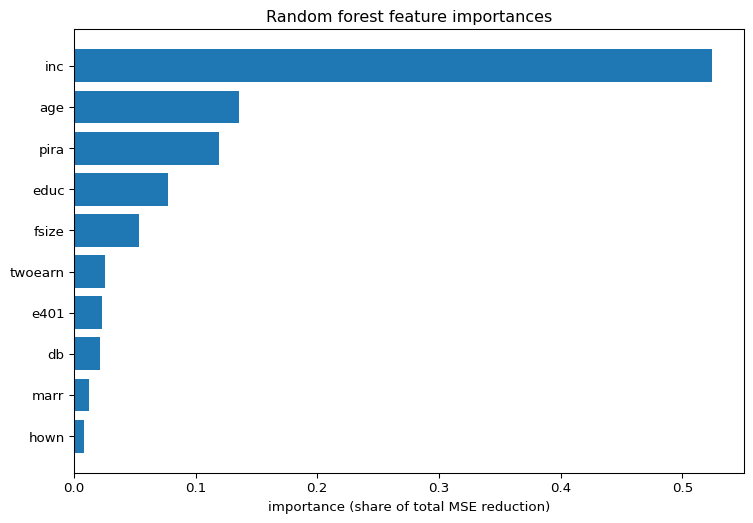

In [11]:
importances = pd.Series(forest.feature_importances_, index=features).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(importances.index, importances.values)
plt.xlabel("importance (share of total MSE reduction)")
plt.title("Random forest feature importances")
plt.show()

Income is by far the most useful feature, followed by age and owning an
IRA. This matches what we read off the single tree. Look at `e401` in
that graph, the eligibility for a 401(k) variable that this whole stream
is building toward. It is near the very bottom, barely used by the
forest at all. It’s a useful diagnostic, but a *predictive* one. We will
find out in notebook 8 that its predictive power says nothing about its
true effect.

## 4. Boosting

Bagging and forests build many trees in parallel and average them.
**Boosting** builds trees in sequence. The first tree makes its
predictions, and the next tree is fit not to the outcome but to the
errors the first one left behind, so it spends its effort on the cases
the aggregate is getting wrong. Add a third tree fit to what the first
two still miss, repeated over many rounds. The trees are kept
deliberately shallow, because each one only has to nudge the running
prediction a little.

We can watch the running prediction build up. Below we boost on income
alone so we can draw it, and plot the ensemble’s fit after 1 round,
after 10, and after 100.

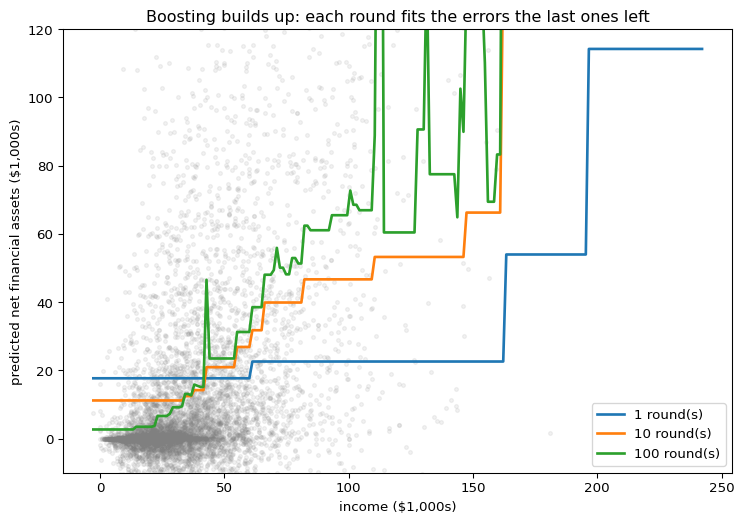

In [12]:
inc1 = X_train[["inc"]]
inc_grid = pd.DataFrame({"inc": np.linspace(inc1["inc"].min(), inc1["inc"].max(), 200)})

gb = GradientBoostingRegressor(n_estimators=200, max_depth=2, random_state=RANDOM_STATE)
gb.fit(inc1, y_train)
stage_preds = list(gb.staged_predict(inc_grid))

plt.figure(figsize=(9, 6))
plt.scatter(inc1["inc"], y_train, s=8, alpha=0.1, color="grey")
for n in [1, 10, 100]:
    plt.plot(inc_grid["inc"], stage_preds[n - 1], linewidth=2, label=f"{n} round(s)")
plt.ylim(-10, 120)
plt.xlabel("income ($1,000s)")
plt.ylabel("predicted net financial assets ($1,000s)")
plt.title("Boosting builds up: each round fits the errors the last ones left")
plt.legend()
plt.show()

After one round the fit is a simple step function. After ten it has bent
toward the data. After one hundred it traces the income-savings
relationship even closer, having spent each new tree on whatever the
running total still got wrong. Now we fit the full boosted model on all
ten features.

In [13]:
boosted = GradientBoostingRegressor(random_state=RANDOM_STATE)
boosted.fit(X_train, y_train)
boosted_mse = mean_squared_error(y_test, boosted.predict(X_test))

print(f"Gradient boosting test MSE: {boosted_mse:.1f}")

Gradient boosting test MSE: 2593.4

Out of the box, boosting is the best predictor we have built on this
data, ahead of KNN and the forest. The gap is small, and it can be
improved further with some fine tuning; the point for us is not which
tree ensemble wins by a few percent, but that both bagging and boosting
take the overfitting tree from section 2 and turn it into a powerful
predictor. In practice the boosting idea is taken further by libraries
like `XGBoost` and `LightGBM`, which are among the most reliable
predictors in everyday use, but the mechanism is the one we just learned
about.

We stop at tree ensembles. Neural networks are another flexible
predictor, you can read more about them [in this
notebook](https://ubcecon.github.io/praxis-ubc/docs/intro_to_deep_learning/intro_to_fundamental_ML.html).

## 5. So have we found the effect of 401(k) eligibility?

Let us line up every model we have fit on this same split.

In [14]:
results = pd.DataFrame({
    "model": ["Predict the mean", "KNN (k=15)", "Single tree (tuned)",
              "Random forest", "Gradient boosting"],
    "test MSE": [baseline_mse, knn_mse, tree_mse, forest_mse, boosted_mse],
})
print(results.round(1).to_string(index=False))

              model  test MSE
   Predict the mean    3708.3
         KNN (k=15)    2654.4
Single tree (tuned)    2784.9
      Random forest    2837.7
  Gradient boosting    2593.4

The flexible methods all beat the baseline and land close together, with
boosting a bit ahead of the others. So we now have a decent predictor of
household savings. Time for the question this stream keeps returning to:

> Do any of these models tell us the **effect** of 401(k) eligibility on
> a household’s savings?

**No!** Look back at the model comparison: the flexible methods cluster
together, and they got there by chasing whatever predicts savings. The
tree opened on owning an IRA because that variable splits savers from
everyone else with the most predictive power, not because we ever showed
that owning an IRA causes savings, and the forest utilizes income and
age for the same reason. Meanwhile `e401`, the eligibility variable this
whole stream is building toward, sat near the bottom of the importance
plot, almost useless for prediction because eligible and ineligible
households already look so different. But that low importance says
nothing about its effect: Notebook 4 builds a world where eligibility
has a real, positive effect that a naive comparison still gets wrong,
and the public-economics literature finds a real effect too. And no
forest (or other predictive technique), ever imagines *this* household
made eligible with everything else held fixed, which is the
counterfactual a causal answer requires. A model can be a fine predictor
and still be useless for the effect we came here to measure. Notebook 4
makes the turn and explains what identifying a treatment effect actually
requires.

> **Its causal future**
>
> The random forest comes back later in a causal disguise. Notebook 8’s
> **causal forest** reuses this notebook’s ideas, re-aimed from
> predicting an outcome to estimating how a treatment effect varies from
> one household to the next.

## Connections

-   **Back to [Notebook
    2](notebook_02_regularization_ridge_lasso.qmd):** ridge and lasso
    were flexible *linear* models, controlled by a penalty.
-   **Forward to [Notebook
    4](notebook_04_prediction_to_treatment_effects.qmd):** we now have
    learned three prediction tools and still cannot answer a causal
    question with any of them. Notebook 4 explains why, and what
    identification requires that prediction does not, and why.

### References

-   Breiman, L. (1996). *Bagging predictors.* Machine Learning, 24(2),
    123-140.
-   Breiman, L. (2001). *Random forests.* Machine Learning, 45(1), 5-32.
-   Chernozhukov, V., Hansen, C., & Spindler, M. (2016). *hdm:
    High-dimensional metrics.* R Journal, 8(2), 185-199. The source of
    the 401(k) dataset.
-   Friedman, J. H. (2001). *Greedy function approximation: a gradient
    boosting machine.* Annals of Statistics, 29(5), 1189-1232.
-   GeeksforGeeks. (2025). *Feature importance with random forests.*
    GeeksforGeeks.
    https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests/
-   James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An
    Introduction to Statistical Learning.* Springer. (Chapter 8.)
-   scikit-learn developers. (n.d.). *1.10. Decision trees.*
    scikit-learn. https://scikit-learn.org/stable/modules/tree.html
-   Wikipedia contributors. (2025). *Bootstrap aggregating.* Wikipedia.
    https://en.wikipedia.org/wiki/Bootstrap_aggregating
-   Wikipedia contributors. (n.d.). *Random forest.* Wikipedia.
    https://en.wikipedia.org/wiki/Random_forest

------------------------------------------------------------------------